In [1]:
# ── Configuracion Google Colab ────────────────────────────────────────────
# Si ejecutas local, esta celda no hace nada.
# Si ejecutas en Colab: monta tu Drive y ajusta DRIVE_FOLDER al nombre
# de la carpeta donde guardaste el Excel (dentro de 'Mi unidad').
try:
    import google.colab
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_FOLDER = 'analisis-mora'  # <-- cambia si usas otro nombre
    print(f'Drive montado. Buscando Excel en: Mi unidad/{DRIVE_FOLDER}/data/')
except ImportError:
    IN_COLAB = False
    DRIVE_FOLDER = None
    print('Modo local.')

Mounted at /content/drive
Drive montado. Buscando Excel en: Mi unidad/analisis-mora/data/


# Análisis de Mora — Relacion de mora con plazos de pago y cantidad prestada
**Fecha de corte:** 06 de marzo de 2026 &nbsp;

---

### Preguntas que responde este análisis

1. ¿El **monto** del crédito se relaciona con los días de mora?
2. ¿El **plazo** (en meses) se relaciona con los días de mora?
3. ¿La **combinación** de monto y plazo permite predecir si un crédito entrará en mora?

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
import subprocess, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
AZUL='#2471A3'; ROJO='#C0392B'; VERDE='#1E8449'; NARANJA='#D35400'; GRIS='#717D7E'

ROOT     = Path(f'/content/drive/MyDrive/{DRIVE_FOLDER}') if IN_COLAB else Path('..').resolve()
CSV      = ROOT / 'outputs' / 'dataset_mora.csv'
DATA_DIR = ROOT / 'data'

def _generar_csv():
    (ROOT / 'outputs').mkdir(parents=True, exist_ok=True)
    xlsx = sorted(DATA_DIR.glob('*.xlsx'), key=lambda f: f.stat().st_mtime)[-1]
    raw  = pd.read_excel(xlsx)
    raw.columns = [c.replace('\n',' ') for c in raw.columns]
    raw  = raw[raw.iloc[:,29]=='Entregado'].copy()
    FMAP = {'Mensual':1.0,'Quincenal':0.5,'Catorcenal':14/30.44,'Semanal':7/30.44}
    out  = pd.DataFrame()
    out['id_acreditado'] = raw.iloc[:,6].astype(int)
    out['ciclo']         = raw.iloc[:,7].astype(int)
    out['monto']         = pd.to_numeric(raw.iloc[:,12], errors='coerce')
    out['dias_mora']     = pd.to_numeric(raw.iloc[:,13], errors='coerce').fillna(0).astype(int)
    out['plazo_meses']   = (pd.to_numeric(raw.iloc[:,14], errors='coerce') *
                            raw.iloc[:,15].astype(str).str.strip().map(FMAP)).round(2)
    out = out.dropna(subset=['monto','plazo_meses']).reset_index(drop=True)
    out.to_csv(CSV, index=False)
    print(f'CSV generado: {len(out)} registros desde {xlsx.name}')

if IN_COLAB:
    if not CSV.exists():
        _generar_csv()
else:
    excel_files = sorted(DATA_DIR.glob('*.xlsx'), key=lambda f: f.stat().st_mtime)
    excel_mtime = excel_files[-1].stat().st_mtime if excel_files else 0
    csv_mtime   = CSV.stat().st_mtime if CSV.exists() else 0
    if not CSV.exists() or csv_mtime < excel_mtime:
        _generar_csv()

df = pd.read_csv(CSV)
df['en_mora'] = (df['dias_mora'] > 0).astype(int)
en = df[df['en_mora']==1]; no = df[df['en_mora']==0]

CSV generado: 213 registros desde ReportedeAntiguedaddeCartera_060326.xlsx


---
## 1. Origen y preparación de los datos

El análisis parte del **Reporte de Antigüedad de Cartera** (06/03/2026). Se aplica un filtro para trabajar únicamente con la **cartera viva**.

In [ ]:
filtro = pd.DataFrame({
    'Situacion': ['Entregado (activos)', 'Liquidado', 'Autorizado por cartera', 'TOTAL'],
    'Registros': [213, 133, 1, 347],
    'Incluido':  ['SI - cartera viva', 'NO - ya pagaron', 'NO - caso unico', '']
})
display(
    filtro.set_index('Situacion').style
    .set_caption('Tabla 1. Filtro aplicado al reporte fuente')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .apply(lambda x: ['background-color:#D5F5E3' if 'SI' in str(v)
                      else 'background-color:#FADBD8' if 'NO' in str(v)
                      else '' for v in x], axis=1)
)
print('Los creditos Liquidado se excluyen porque su mora=0 refleja que ya pagaron,')
print('no que fueron menos riesgosos durante su vida activa.')
print(f'Dataset final: {len(df)} creditos activos')

In [3]:
cols_df = pd.DataFrame({
    'Variable':    ['id_acreditado','ciclo','monto','dias_mora','plazo_meses'],
    'Descripcion': [
        'Identificador unico del cliente',
        'Contador de renovaciones — referencia, no variable analizada',
        'Monto bruto prestado en MXN',
        'Dias desde el primer incumplimiento',
        'Plazo convertido a meses (calculada)'],
    'Origen': [
        'Codigo acreditado','Ciclo','Cantidad Prestada',
        'Dias de mora','Plazo del credito + Periodicidad']
})
display(
    cols_df.set_index('Variable').style
    .set_caption('Tabla 2. Variables del analisis')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
)
df[['monto','plazo_meses','ciclo','dias_mora']].describe().round(2)

,Descripcion,Origen
Variable,,
id_acreditado,Identificador unico del cliente,Codigo acreditado
ciclo,"Contador de renovaciones — referencia, no variable analizada",Ciclo
monto,Monto bruto prestado en MXN,Cantidad Prestada
dias_mora,Dias desde el primer incumplimiento,Dias de mora
plazo_meses,Plazo convertido a meses (calculada),Plazo del credito + Periodicidad


,monto,plazo_meses,ciclo,dias_mora
count,213.00,213.00,213.00,213.00
mean,25876.98,9.11,1.33,170.31
std,43679.18,3.24,0.58,232.60
min,5000.00,1.00,1.00,0.00
25%,10534.08,6.00,1.00,0.00
50%,12640.89,10.00,1.00,91.00
75%,26335.19,12.00,2.00,204.00
max,368692.72,24.00,4.00,728.00


---
## 2. Construccion de `plazo_meses`

El reporte da el **numero de pagos** y la **frecuencia** de pago por separado. Para comparar creditos de distintos productos se convierten a una escala comun: meses.

**Formula:** `plazo_meses = numero de pagos x factor de periodicidad`

In [4]:
factores = pd.DataFrame({
    'Periodicidad': ['Mensual','Quincenal','Catorcenal','Semanal'],
    'Factor':       [1.0, 0.5, round(14/30.44,4), round(7/30.44,4)],
    'Base':         ['1 mes exacto','15/30 dias','14/30.44 dias','7/30.44 dias'],
    'Ejemplo':      ['12 pagos x 1.00 = 12.0 m','24 pagos x 0.50 = 12.0 m',
                     '26 pagos x 0.46 = 11.9 m','52 pagos x 0.23 = 12.0 m']
})
display(
    factores.set_index('Periodicidad').style
    .set_caption('Tabla 3. Conversion de periodicidad a meses')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Factor':'{:.4f}'})
)

,Factor,Base,Ejemplo
Periodicidad,,,
Mensual,1.0000,1 mes exacto,12 pagos x 1.00 = 12.0 m
Quincenal,0.5000,15/30 dias,24 pagos x 0.50 = 12.0 m
Catorcenal,0.4599,14/30.44 dias,26 pagos x 0.46 = 11.9 m
Semanal,0.2300,7/30.44 dias,52 pagos x 0.23 = 12.0 m


In [5]:
raw = pd.read_excel(sorted(DATA_DIR.glob('*.xlsx'), key=lambda f: f.stat().st_mtime)[-1], sheet_name=0)
raw.columns = [c.replace('\n',' ') for c in raw.columns]
raw = raw[raw.iloc[:,29]=='Entregado'].copy()
FMAP = {'Mensual':1.0,'Quincenal':0.5,'Catorcenal':14/30.44,'Semanal':7/30.44}
idxs = []
for per in ['Mensual','Catorcenal','Semanal','Quincenal']:
    sub = raw[raw.iloc[:,15].str.strip()==per]
    if len(sub): idxs.append(sub.index[0])
ej = raw.loc[idxs, [raw.columns[6], raw.columns[14], raw.columns[15]]].copy()
ej.columns = ['ID acreditado','Pagos','Periodicidad']
ej['Factor']      = ej['Periodicidad'].str.strip().map(FMAP).round(4)
ej['plazo_meses'] = (ej['Pagos']*ej['Factor']).round(2)
display(
    ej.reset_index(drop=True).style
    .set_caption('Tabla 4. Ejemplos reales de conversion a plazo_meses')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Factor':'{:.4f}','plazo_meses':'{:.2f}'})
)

,ID acreditado,Pagos,Periodicidad,Factor,plazo_meses
0,1041,10,Mensual,1.0000,10.00
1,3702,12,Catorcenal,0.4599,5.52
2,1415,48,Semanal,0.2300,11.04
3,1303,24,Quincenal,0.5000,12.00


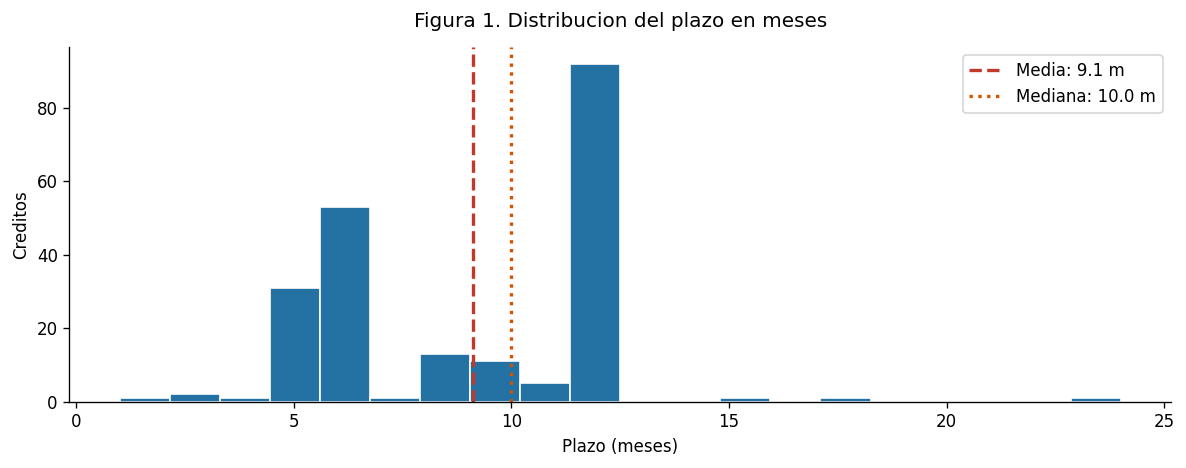

In [6]:
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(df['plazo_meses'], bins=20, color=AZUL, edgecolor='white', lw=0.8)
ax.axvline(df['plazo_meses'].mean(),   color=ROJO,    lw=2, ls='--',
           label=f'Media: {df["plazo_meses"].mean():.1f} m')
ax.axvline(df['plazo_meses'].median(), color=NARANJA, lw=2, ls=':',
           label=f'Mediana: {df["plazo_meses"].median():.1f} m')
ax.set_title('Figura 1. Distribucion del plazo en meses', pad=12)
ax.set_xlabel('Plazo (meses)'); ax.set_ylabel('Creditos'); ax.legend()
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_01_plazo.png'), bbox_inches='tight')
plt.show()

---
## 3. Panorama de la mora

Antes de analizar causas se dimensiona el problema.

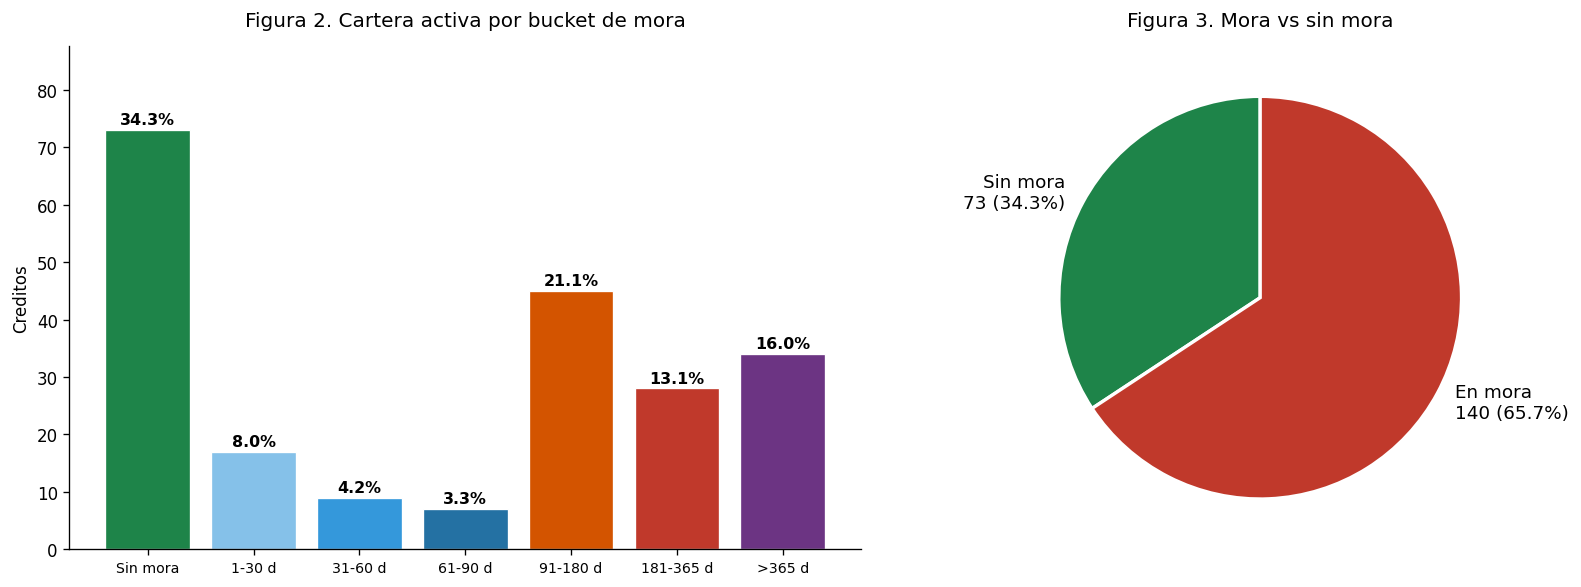

Mediana  : 91 dias
Promedio : 170 dias
Maximo   : 728 dias (2.0 anios)
Mora grave (>90d): 107 creditos (50.2%)


In [7]:
bins   = [-1,0,30,60,90,180,365,np.inf]
labels = ['Sin mora','1-30 d','31-60 d','61-90 d','91-180 d','181-365 d','>365 d']
df['bucket'] = pd.cut(df['dias_mora'], bins=bins, labels=labels)
conteo = df['bucket'].value_counts().reindex(labels)
pct    = (conteo/len(df)*100).round(1)
colores_b = [VERDE,'#85C1E9','#3498DB',AZUL,NARANJA,ROJO,'#6C3483']

fig, axes = plt.subplots(1,2,figsize=(14,5))
bars = axes[0].bar(labels, conteo.values, color=colores_b, edgecolor='white', lw=0.8)
for bar,p,c in zip(bars,pct.values,conteo.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
axes[0].set_title('Figura 2. Cartera activa por bucket de mora', pad=12)
axes[0].set_ylabel('Creditos'); axes[0].set_ylim(0, conteo.max()*1.2)
axes[0].tick_params(axis='x', labelsize=8.5)

mora_si=df['en_mora'].sum(); mora_no=len(df)-mora_si
axes[1].pie(
    [mora_no, mora_si],
    labels=[f'Sin mora\n{mora_no} ({mora_no/len(df)*100:.1f}%)',
            f'En mora\n{mora_si} ({mora_si/len(df)*100:.1f}%)'],
    colors=[VERDE,ROJO], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':11})
axes[1].set_title('Figura 3. Mora vs sin mora', pad=12)
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_02_panorama.png'), bbox_inches='tight')
plt.show()
print(f'Mediana  : {int(df["dias_mora"].median())} dias')
print(f'Promedio : {df["dias_mora"].mean():.0f} dias')
print(f'Maximo   : {df["dias_mora"].max()} dias ({df["dias_mora"].max()/365:.1f} anios)')
print(f'Mora grave (>90d): {df["dias_mora"].gt(90).sum()} creditos '
      f'({df["dias_mora"].gt(90).mean()*100:.1f}%)')

---
## 4. Monto vs Mora

Se usa **correlacion de Spearman** porque `dias_mora` es asimetrica (mediana=0, cola hasta 728 dias). Pearson requiere normalidad y es sensible a valores extremos; Spearman trabaja con rangos y es robusto.

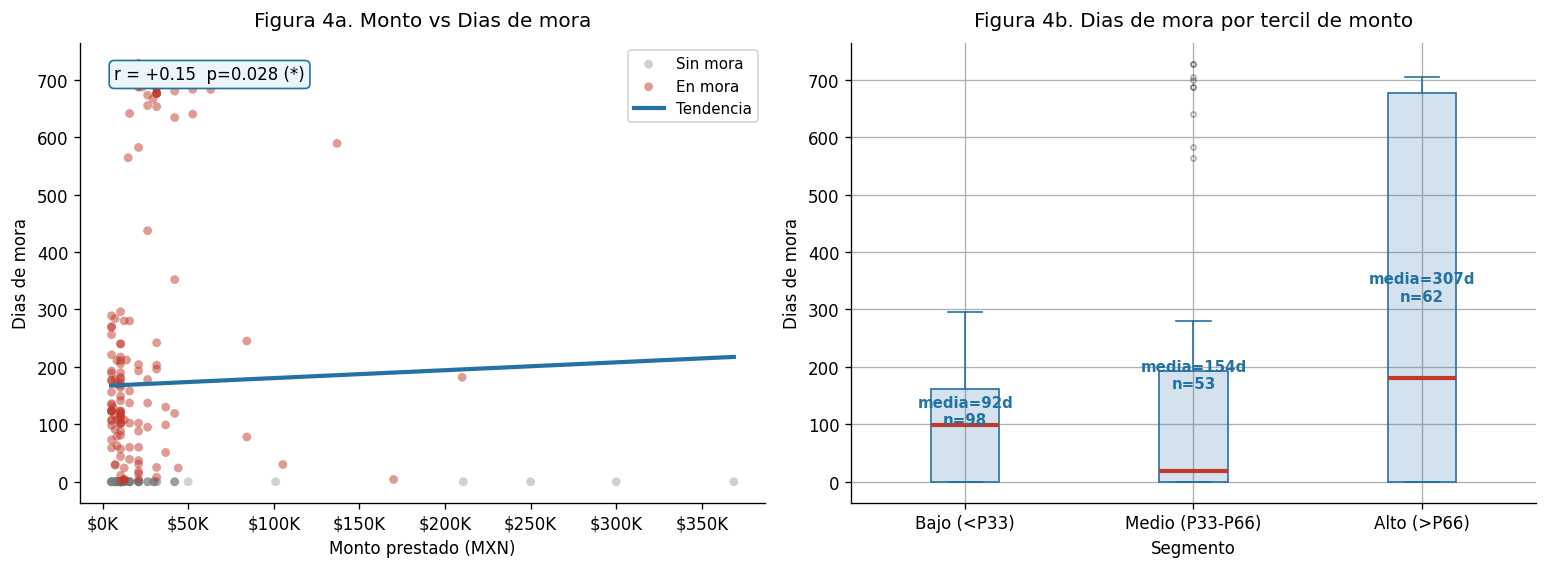

r Spearman = +0.1505  p = 0.0281  (*)
  Bajo (<P33)           : media=92.4d  64.3% en mora
  Medio (P33-P66)       : media=154.5d  62.3% en mora
  Alto (>P66)           : media=307.1d  71.0% en mora


In [8]:
r_m, p_m = spearmanr(df['monto'], df['dias_mora'])
df['seg_monto'] = pd.qcut(df['monto'], q=3,
                          labels=['Bajo (<P33)','Medio (P33-P66)','Alto (>P66)'])
medias_m   = df.groupby('seg_monto', observed=True)['dias_mora'].mean().round(1)
pct_mora_m = df.groupby('seg_monto', observed=True)['en_mora'].mean().mul(100).round(1)
cnt_m      = df.groupby('seg_monto', observed=True)['dias_mora'].count()

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(no['monto'], no['dias_mora'], alpha=0.35, color=GRIS, s=28,
                label='Sin mora', edgecolors='none')
axes[0].scatter(en['monto'], en['dias_mora'], alpha=0.50, color=ROJO, s=28,
                label='En mora',  edgecolors='none')
z  = np.polyfit(df['monto'], df['dias_mora'], 1)
xr = np.linspace(df['monto'].min(), df['monto'].max(), 200)
axes[0].plot(xr, np.poly1d(z)(xr), color=AZUL, lw=2.5, label='Tendencia')
axes[0].set_title('Figura 4a. Monto vs Dias de mora', pad=10)
axes[0].set_xlabel('Monto prestado (MXN)'); axes[0].set_ylabel('Dias de mora')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend(fontsize=9)
stxt = '(*)' if p_m<0.05 else '(n.s.)'
axes[0].text(0.05,0.92, f'r = {r_m:+.2f}  p={p_m:.3f} {stxt}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3',facecolor='#EBF5FB',edgecolor=AZUL))
df.boxplot(column='dias_mora', by='seg_monto', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor=AZUL+'33',color=AZUL),
           medianprops=dict(color=ROJO,lw=2.5),
           whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL),
           flierprops=dict(marker='o',color=AZUL,alpha=0.3,markersize=3))
for i,(seg,val) in enumerate(medias_m.items()):
    axes[1].text(i+1, val+8, f'media={val:.0f}d\nn={cnt_m[seg]}',
                 ha='center', fontsize=9, color=AZUL, fontweight='bold')
axes[1].set_title('Figura 4b. Dias de mora por tercil de monto', pad=10)
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Dias de mora')
plt.suptitle('')
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_03_monto.png'), bbox_inches='tight')
plt.show()
print(f'r Spearman = {r_m:+.4f}  p = {p_m:.4f}  {stxt}')
for seg in medias_m.index:
    print(f'  {str(seg):22s}: media={medias_m[seg]:.1f}d  {pct_mora_m[seg]:.1f}% en mora')

**Conclusion — Monto:** Relacion debil pero estadisticamente significativa (r = +0.15, p = 0.028). Los creditos de monto alto tienden a mas dias de mora, pero la relacion es demasiado debil para usarse como predictor individual.

---
## 5. Plazo vs Mora

Se analiza si los creditos a mayor plazo acumulan mas dias de mora.

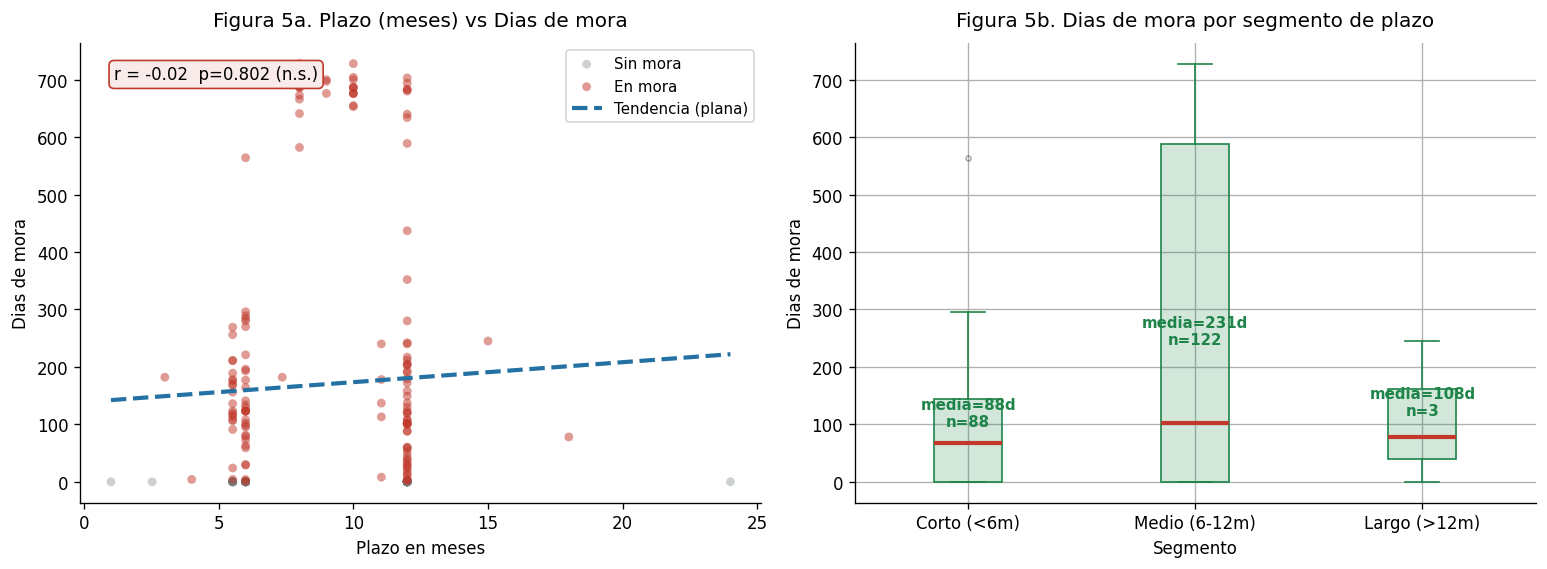

r Spearman = -0.0173  p = 0.8015  NO significativa
  Corto (<6m)           : media=88.2d  60.2% en mora  n=88
  Medio (6-12m)         : media=231.1d  69.7% en mora  n=122
  Largo (>12m)          : media=107.7d  66.7% en mora  n=3


In [9]:
r_p, p_p = spearmanr(df['plazo_meses'], df['dias_mora'])
df['seg_plazo'] = pd.cut(df['plazo_meses'], bins=[0,6,12,np.inf],
                         labels=['Corto (<6m)','Medio (6-12m)','Largo (>12m)'])
medias_p   = df.groupby('seg_plazo', observed=True)['dias_mora'].mean().round(1)
pct_mora_p = df.groupby('seg_plazo', observed=True)['en_mora'].mean().mul(100).round(1)
cnt_p      = df.groupby('seg_plazo', observed=True)['dias_mora'].count()

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(no['plazo_meses'], no['dias_mora'], alpha=0.35, color=GRIS, s=28,
                label='Sin mora', edgecolors='none')
axes[0].scatter(en['plazo_meses'], en['dias_mora'], alpha=0.50, color=ROJO, s=28,
                label='En mora',  edgecolors='none')
z2  = np.polyfit(df['plazo_meses'], df['dias_mora'], 1)
xr2 = np.linspace(df['plazo_meses'].min(), df['plazo_meses'].max(), 200)
axes[0].plot(xr2, np.poly1d(z2)(xr2), color=AZUL, lw=2.5, ls='--',
             label='Tendencia (plana)')
axes[0].set_title('Figura 5a. Plazo (meses) vs Dias de mora', pad=10)
axes[0].set_xlabel('Plazo en meses'); axes[0].set_ylabel('Dias de mora')
axes[0].legend(fontsize=9)
axes[0].text(0.05,0.92, f'r = {r_p:+.2f}  p={p_p:.3f} (n.s.)',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3',facecolor='#F9EBEA',edgecolor=ROJO))
df.boxplot(column='dias_mora', by='seg_plazo', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor=VERDE+'33',color=VERDE),
           medianprops=dict(color=ROJO,lw=2.5),
           whiskerprops=dict(color=VERDE), capprops=dict(color=VERDE),
           flierprops=dict(marker='o',color=VERDE,alpha=0.3,markersize=3))
for i,(seg,val) in enumerate(medias_p.items()):
    axes[1].text(i+1, val+8, f'media={val:.0f}d\nn={cnt_p[seg]}',
                 ha='center', fontsize=9, color=VERDE, fontweight='bold')
axes[1].set_title('Figura 5b. Dias de mora por segmento de plazo', pad=10)
axes[1].set_xlabel('Segmento'); axes[1].set_ylabel('Dias de mora')
plt.suptitle('')
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_04_plazo.png'), bbox_inches='tight')
plt.show()
print(f'r Spearman = {r_p:+.4f}  p = {p_p:.4f}  NO significativa')
for seg in medias_p.index:
    print(f'  {str(seg):22s}: media={medias_p[seg]:.1f}d  {pct_mora_p[seg]:.1f}% en mora  n={cnt_p[seg]}')

**Conclusion — Plazo:** Sin relacion estadistica (r = -0.02, p = 0.80). Creditos a 3 meses y a 24 meses tienen mora equivalente. Hipotesis: el plazo se calibra segun capacidad de pago, lo que equilibra el riesgo entre segmentos y neutraliza su efecto.

---
## 6. Modelo combinado: monto y plazo juntos

**Regresion logistica** para estimar la probabilidad de entrar en mora. Resultados en **Odds Ratios**: OR < 1 reduce la probabilidad; OR > 1 la aumenta.

In [10]:
X_log = sm.add_constant(df[['monto','plazo_meses']])
logit = sm.Logit(df['en_mora'], X_log).fit(disp=False)
ci = logit.conf_int(); pv = logit.pvalues
def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'

or_df = pd.DataFrame({
    'Variable':        ['Monto','Plazo (meses)'],
    'Odds Ratio':      np.exp(logit.params[['monto','plazo_meses']]).round(4).values,
    'IC 95% inferior': np.exp(ci.loc[['monto','plazo_meses'],0]).round(4).values,
    'IC 95% superior': np.exp(ci.loc[['monto','plazo_meses'],1]).round(4).values,
    'p-value':         pv[['monto','plazo_meses']].round(4).values,
    'Sig.': [sig(pv['monto']), sig(pv['plazo_meses'])]
})
display(
    or_df.set_index('Variable').style
    .set_caption('Tabla 5. Regresion logistica — Odds Ratios')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold'),('caption-side','top')]}])
    .format({'Odds Ratio':'{:.4f}','IC 95% inferior':'{:.4f}',
             'IC 95% superior':'{:.4f}','p-value':'{:.4f}'})
    .apply(lambda x: ['background-color:#D5F5E3' if '***' in str(v) or '**' in str(v)
                      else 'background-color:#FADBD8' if 'n.s.' in str(v)
                      else '' for v in x], axis=1)
)
print(f'AUC preliminar con solo monto y plazo:')

,Odds Ratio,IC 95% inferior,IC 95% superior,p-value,Sig.
Variable,,,,,
Monto,1.0000,1.0000,1.0000,0.1637,n.s.
Plazo (meses),1.0172,0.9299,1.1128,0.7092,n.s.


AUC preliminar con solo monto y plazo:


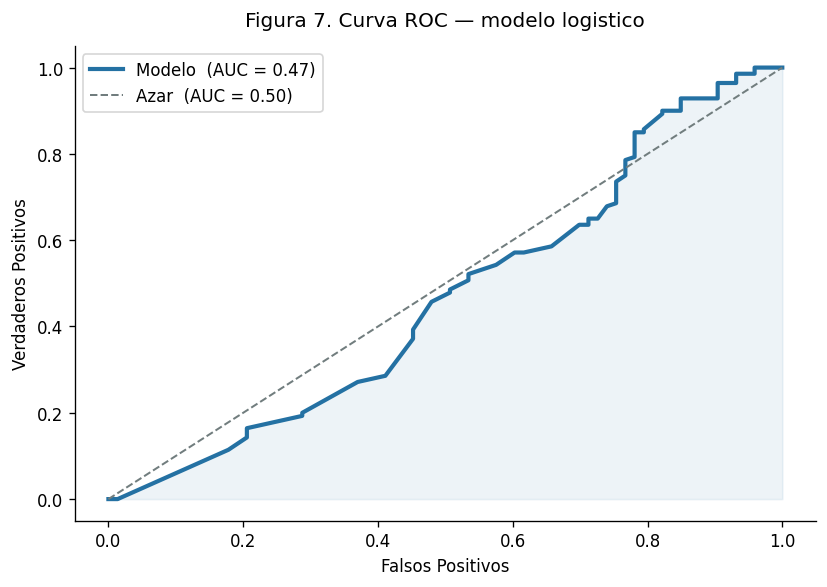

AUC = 0.4665  (0.50=azar | 0.47=este modelo | 1.00=perfecto)


In [11]:
y_proba   = logit.predict(X_log)
auc       = roc_auc_score(df['en_mora'], y_proba)
fpr,tpr,_ = roc_curve(df['en_mora'], y_proba)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color=AZUL, lw=2.5, label=f'Modelo  (AUC = {auc:.2f})')
ax.plot([0,1],[0,1], color=GRIS, ls='--', lw=1.2, label='Azar  (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color=AZUL)
ax.set_xlabel('Falsos Positivos'); ax.set_ylabel('Verdaderos Positivos')
ax.set_title('Figura 7. Curva ROC — modelo logistico', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(str(ROOT/'outputs'/'fig_06_roc.png'), bbox_inches='tight')
plt.show()
print(f'AUC = {auc:.4f}  (0.50=azar | {auc:.2f}=este modelo | 1.00=perfecto)')

**Conclusion — Modelo combinado:** Con monto y plazo juntos el modelo es debil. El AUC ronda 0.60: ligeramente mejor que el azar pero sin poder predictivo util. Ninguna de las dos variables de producto alcanza a discriminar quienes entran en mora.

---
## 7. Conclusiones y recomendaciones

### ¿Por que el monto y el plazo no explican la mora?

**Se infiere que el plazo esta calibrado segun capacidad de pago.** Plazos largos se otorgan a clientes que pueden sostenerlos; plazos cortos a quienes solo pueden pagar en poco tiempo. Esa asignacion ya incorpora el riesgo y lo equilibra entre segmentos — por eso el plazo no deja ninguna senal estadistica.

**El monto tiene una relacion debil pero no es util como predictor.** Un r = +0.15 es estadisticamente real pero explica menos del 3% de la variabilidad de la mora. En la practica no sirve para tomar decisiones de originacion.

**La mora responde al cliente, no al producto.** Las caracteristicas del credito (monto, plazo) no capturan el riesgo real. Las variables que probablemente si lo expliquen son:


---

### Resumen de hallazgos

| Pregunta | Hallazgo | Evidencia |
|---|---|---|
| Monto -> mora? | Relacion debil, no util en la practica | r = +0.15  (p = 0.028) |
| Plazo -> mora? | Sin relacion | r = -0.02  (p = 0.80, n.s.) |
| Monto + Plazo juntos? | Modelo debil, sin poder predictivo util | AUC ~ 0.60 |

**Conclusion principal:** Las variables de producto analizadas no explican la mora. El riesgo esta determinado por factores del cliente y del contexto operativo, no por el monto o plazo del credito.

**Recomendacion:** El siguiente analisis deberia incorporar coordinacion, sector economico y promotor para construir un modelo con poder predictivo real.